# Amazon Book Review Analysis

Initializing Packages

In [19]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# NLP
from textblob import TextBlob
from collections import Counter

# Vectorization / keywords
from sklearn.feature_extraction.text import CountVectorizer

# Wordcloud
from wordcloud import WordCloud

# Stopwords
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

sns.set(style="whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading in data

In [20]:
plt.rcParams["figure.figsize"] = (10, 6)

books = pd.read_csv("E:/Python Files/Book Review/books.csv")
reviews = pd.read_csv("E:/Python Files/Book Review/reviews.csv")

print(books.head())
print(reviews.head())

   Rank                                         book title  book price  \
0     1                       Iron Flame (The Empyrean, 2)       18.42   
1     2                                    The Woman in Me       20.93   
2     3                                  My Name Is Barbra       31.50   
3     4  Friends, Lovers, and the Big Terrible Thing: A...       23.99   
4     5                              How to Catch a Turkey        5.65   

   rating            author  year of publication               genre  \
0     4.1    Rebecca Yarros                 2023     Fantasy Romance   
1     4.5    Britney Spears                 2023              Memoir   
2     4.5  Barbra Streisand                 2023       Autobiography   
3     4.4     Matthew Perry                 2023              Memoir   
4     4.8      Adam Wallace                 2018  Childrens, Fiction   

                                                 url  
0  amazon.com/Iron-Flame-Empyrean-Rebecca-Yarros/...  
1  amazon.co

Merging both datasets

In [21]:
# Merge (adjust column names accordingly)
df = pd.merge(
    reviews,
    books,
    left_on="book name",
    right_on="book title",
    how="left"
)

**Cleaning Texts Data**

In [22]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(f"[{string.punctuation}]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

**Review Length Analysis**

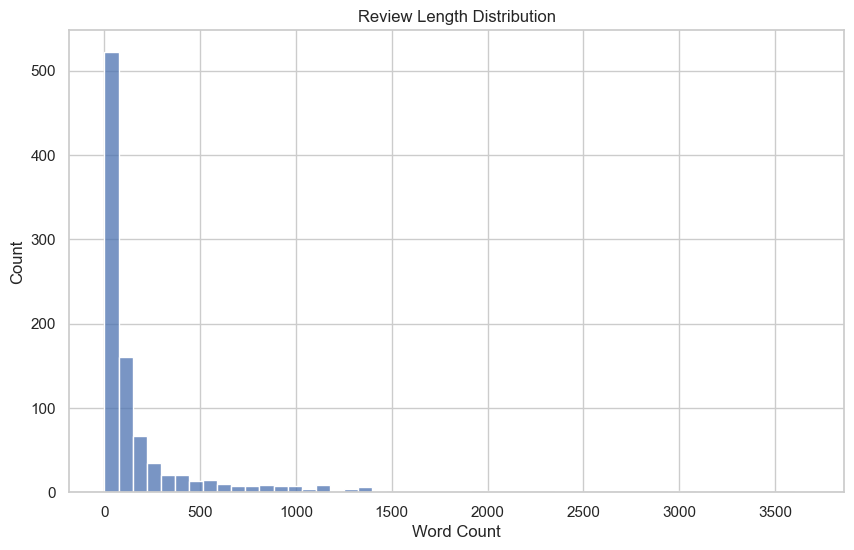

In [23]:
df["review_text"] = df["review description"].astype(str)

df["review_length"] = df["review_text"].apply(lambda x: len(x.split()))

df["review_length"] = df["review_text"].apply(lambda x: len(str(x).split()))

sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.show()

**Review Length Vs Rating**

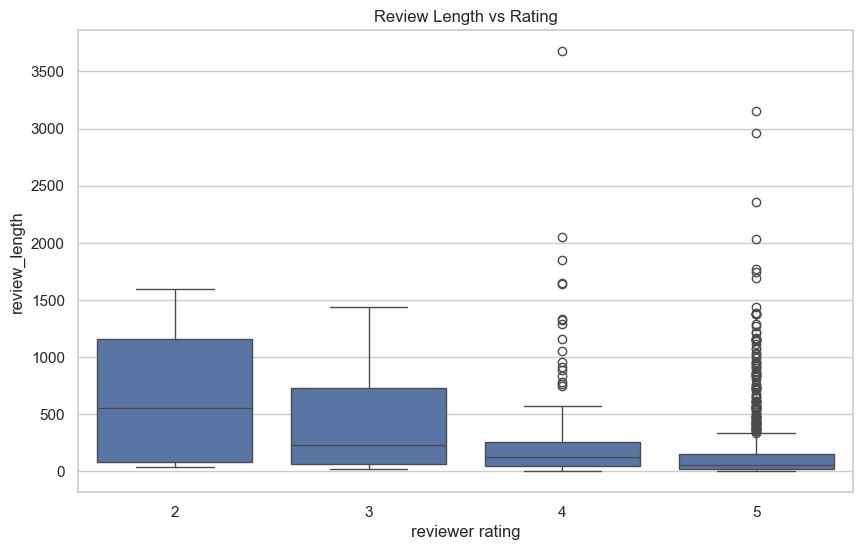

In [24]:
sns.boxplot(x="reviewer rating", y="review_length", data=df)
plt.title("Review Length vs Rating")
plt.show()

**Top Keywords**

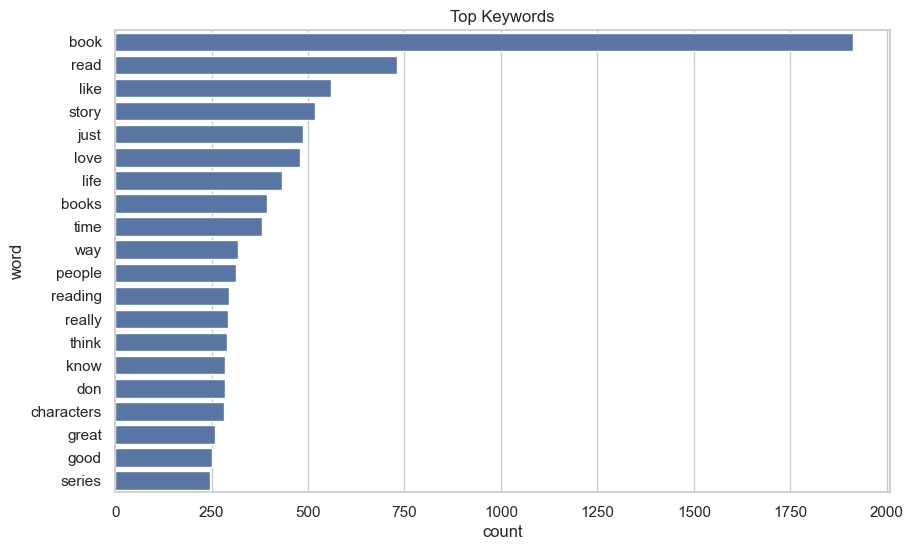

In [25]:
vectorizer = CountVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(df["review_text"])

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

keywords_df = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values(by="count", ascending=False)

sns.barplot(data=keywords_df, x="count", y="word")
plt.title("Top Keywords")
plt.show()

**Polarity Distribution**

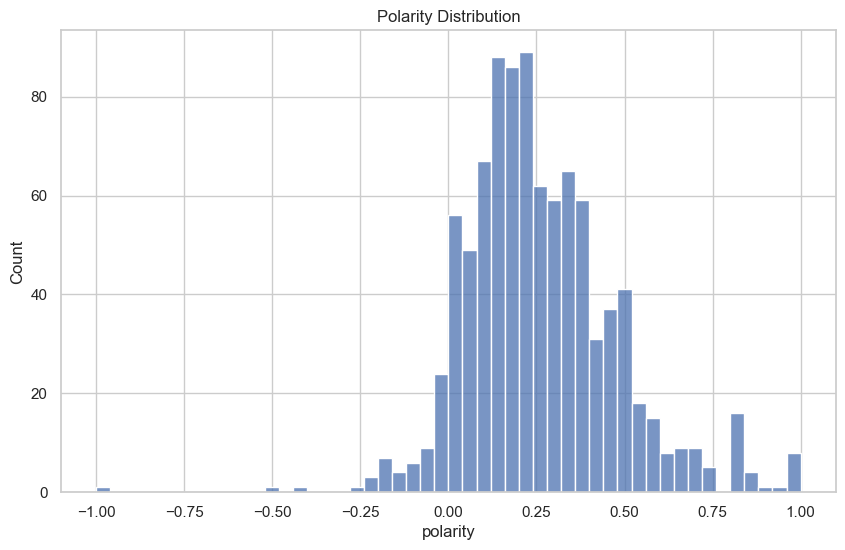

In [26]:
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[["polarity", "subjectivity"]] = df["review_text"].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Polarity
sns.histplot(df["polarity"], bins=50)
plt.title("Polarity Distribution")
plt.show()

**Subjectivity Distribution**

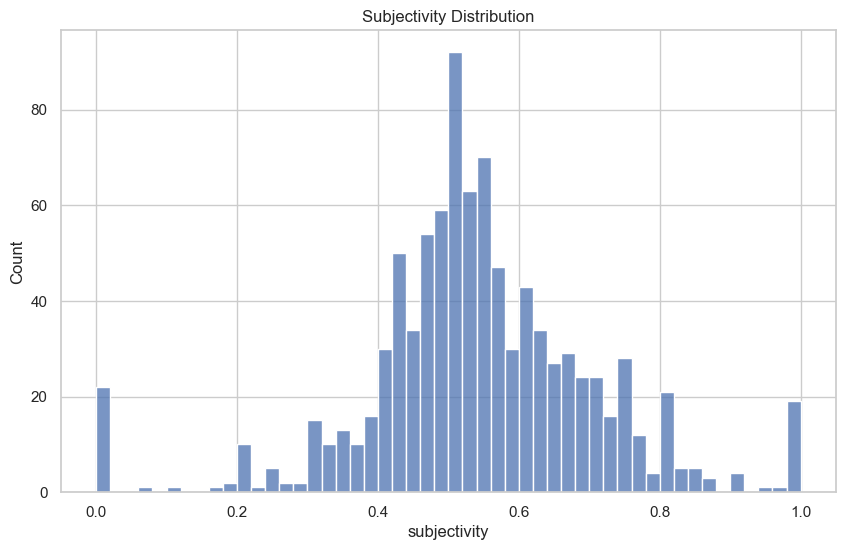

In [27]:
# Subjectivity
sns.histplot(df["subjectivity"], bins=50)
plt.title("Subjectivity Distribution")
plt.show()

**Ratings Vs Sentiment**

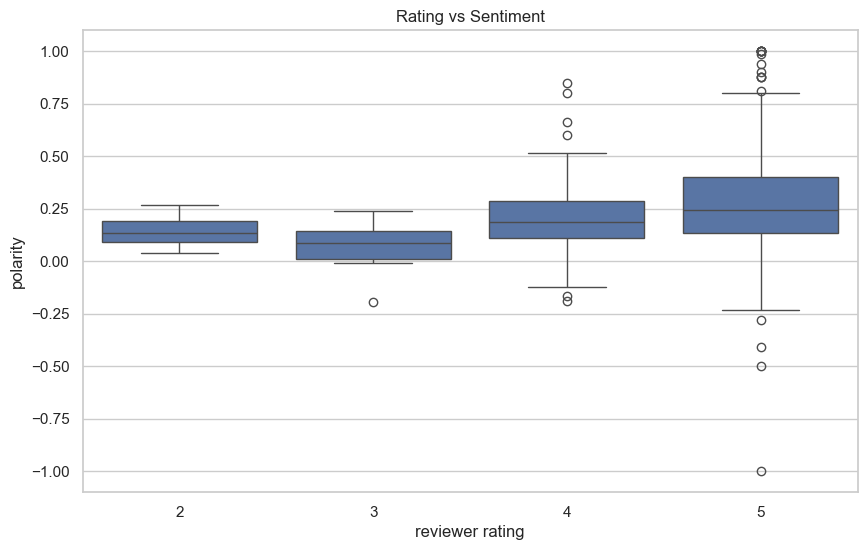

In [28]:
sns.boxplot(x="reviewer rating", y="polarity", data=df)
plt.title("Rating vs Sentiment")
plt.show()

**Word Cloud of Review texts** highlighting most used words in reviews

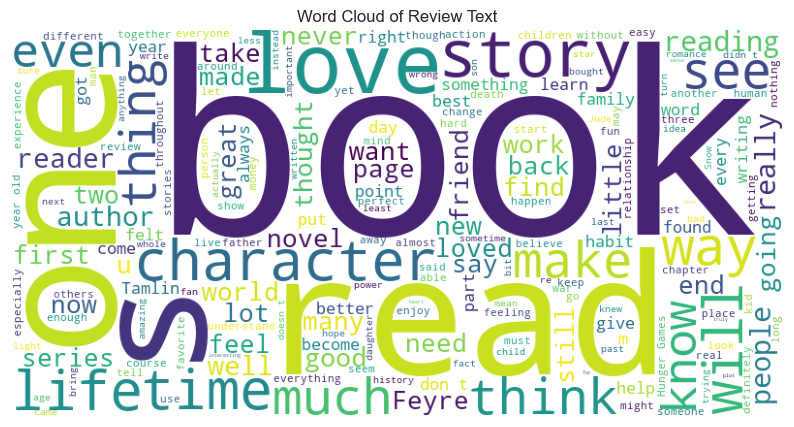

In [29]:
text = " ".join(df["review_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Review Text")
plt.show()

**Word Cloud of Review Title** highlighting most used words in Review Title

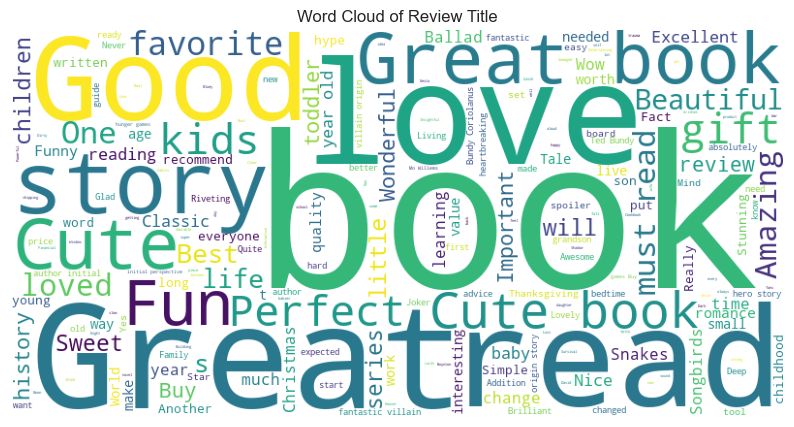

In [30]:
text = " ".join(df["review title"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Review Title")
plt.show()

**Sentiment Classification** (Authors with highest sentiment amongst reviews)

In [31]:
df["sentiment"] = df["polarity"].apply(
    lambda x: "positive" if x > 0 else "negative" if x < 0 else "neutral"
)

df.groupby("author")["polarity"].mean().sort_values(ascending=False).head(10)

author
Leigh Olsen              0.465469
Emily Winfield Martin    0.463636
Wendi Silvano            0.446438
Lucille Colandro         0.446373
Eric Hill                0.427000
Mo Willems               0.422469
Eric Carle               0.412801
Taylor Jenkins Reid      0.411580
David Brooks             0.402220
Rose Rossner             0.395758
Name: polarity, dtype: float64